Linear Regression is a supervised ML model dedicated to regression tasks, it tries to find linear correlation between one or more independent variables with the dependent one.

### 1 . Hypothetical function :
---

Who says linear correlation says afine function, so if we want to find the right equation for our model we will right :

$$\hat{Y} = b + \theta_1x_1 + \theta_2x_2 + ... + \theta_nx_n$$

with $b$ as the biais, and $ \theta_i $ as the weights of our model.


### 2 . Cost function :
---

We need now to set a specific function to calculate the error of our model since it is not perfect, we call this function $cost function$ :

<blockquote> Cost function is a error function which is used to find the error term of a model on a data.
    In our case, $\hat{y}_i$ is the model’s output label. And $y_i$ is the true label. We find the deviation of the actual label and true label. This is a linear case. We know, the value of $\hat{y}_i - y_i$ can be +ve or -ve. And when doing summation, -ve and +ve gets canceled out. So we need to square them and sum it. We will also find mean of. 
</blockquote>
<blockquote>
    There are varients of cost function for regression. Like:- Mean Squard Error(MSE), Mean Absolute Error(MAE) etc. </blockquote>
    
For our example we choose working with the MSE :

$$J(\theta) = \frac{1}{2m}\sum \limits _{i=1} ^{m} (\hat{y}_i - y_i)^2 $$

For just two variables with $\theta_0$ is our biais b, we get the shape in the picture :

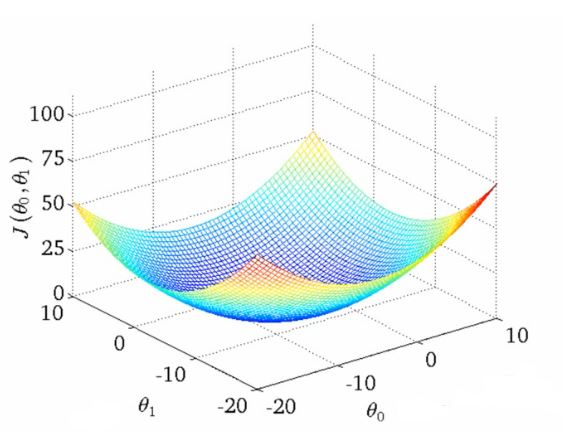

### 3 . Gradient descent and updates :
---

Can you set directly the parameters of our Hypothetical function and get the precise predictions you are looking for?! Obviously No even with a little chance! 

If we change randomly the values we may pick the best ones but in the same time our chance to be lost is too large!

Indeed, the only efficient way is to get these parameters when the cost function is in its minimum.

and that is the concept of the famous method Gradient Descent.

<blockquote> Gradient Descent algorithm will change, at each iteration, the values of all $\theta_i$ and the biais $b$ until the best possible combinaition of parameters is found. </blockquote>
    
   
Imagine that you are on a hill, and you want to go down it. With each new step (analogy to iteration), you look around to find the best slope to move down. Once you have found the slope, you take a step forward one magnitude $\alpha$.

Here is an example with one variable how it looks, with w is our parameter in that case :


<img src="https://cdn-images-1.medium.com/max/1600/0*fU8XFt-NCMZGAWND." width="400"></img>


<br>

Here are the formulas of Gradient Descent for the hypothesis function we are working on from the beginning :

$$ \theta_i = \theta_i - \alpha d\theta_i$$

$$ b = b - \alpha db$$

Here are the derivatives we need, you can replace them in the equations :

$$d \theta_i = - \frac{2}{m} \sum \limits _{i=1} ^{m} x_i (\hat{y_i} - y)$$

$$d b = - \frac{2}{m}\sum \limits _{i=1} ^{m} (\hat{y_i} - y)$$


## It's time for coding :

We choose to work with OOP since it is appropriate with that kind of problems, and all models are implemented using OOP in Sickit learn.

The two functions we need to code are fit and predict, the first one is for model training, i.e it will find the parameters of our model based on the number of iterations and learning rate we are working with; and the second one to get the predictions for new samples.

In [1]:
# we import libraries we need for the implimantation
import numpy as np
import pandas as pd

In [2]:
class LinearRegression() :
    def __init__( self, lr=0.001, epochs=1000 ) :
        self.lr = lr
        self.epochs = epochs

    # Function for model training
    def fit( self, X, Y ) :
        # no_of_training_examples, no_of_features
        self.m, self.n = X.shape

        # weight initialization
        self.W = np.zeros( self.n )
        self.b = 0
        self.X = X
        self.Y = Y
        
        # gradient descent learning
        for i in range( self.epochs ) :
            y_pred = self.predict( self.X )
            # calculate gradients
            dW = - ( 2 * ( self.X.T ).dot( self.Y - y_pred ) ) / self.m
            db = - 2 * np.sum( self.Y - y_pred ) / self.m
            # update weights
            self.W = self.W - self.lr * dW
            self.b = self.b - self.lr * db

        return self


    # Hypothetical function 
    def predict( self, X ) :
        return X.dot( self.W ) + self.b

Let's apply it on House Price dataset.

For pre-processing part I just copied it from one of my previous kernels in this competition, you can take a look at it if you don't understand something.

In [3]:
from scipy.stats import skew 
from sklearn.model_selection import train_test_split

train = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv', index_col='Id')
test = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv', index_col='Id')

train.SalePrice = np.log1p(train.SalePrice)

df = train.append(test).reset_index(drop=True)

df['Functional'] = df['Functional'].fillna('Typ')
df['Electrical'] = df['Electrical'].fillna("SBrkr") # Standard Circuit
df['KitchenQual'] = df['KitchenQual'].fillna("TA")

df['Exterior1st'] = df['Exterior1st'].fillna(train['Exterior1st'].mode()[0])
df['Exterior2nd'] = df['Exterior2nd'].fillna(train['Exterior2nd'].mode()[0])
df['SaleType'] = df['SaleType'].fillna(train['SaleType'].mode()[0])

for col in ["PoolQC", "Alley", 'FireplaceQu', 'Fence', 'MiscFeature', 'GarageType', 'GarageFinish', 'GarageQual', 
            'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', "MasVnrType"] :
    
    df[col] = df[col].fillna("None")
    
for col in ('GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'BsmtFullBath', 'BsmtHalfBath', 
            'TotalBsmtSF', "MasVnrArea"):
    df[col] = df[col].fillna(0) # no basement or no garage

df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
df['MSZoning'] = df.groupby('MSSubClass')['MSZoning'].transform(lambda x: x.fillna(x.mode()[0]))

to_drop = ['GarageYrBlt','YearRemodAdd', 'Utilities'] 
df = df.drop(to_drop, axis = 1)

df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['Total_Home_Quality'] = df['OverallQual'] + df['OverallCond']

df['MSSubClass'] = df['MSSubClass'].apply(str)
df['OverallCond'] = df['OverallCond'].astype(str)
df['YrSold'] = df['YrSold'].apply(str)
df['MoSold'] = df['MoSold'].apply(str)

df = pd.get_dummies(df)

numeric_features = df.dtypes[df.dtypes != object].index
skewed_features = df[numeric_features].apply(lambda x: skew(x)).sort_values(ascending=False)
high_skew = skewed_features[skewed_features > 0.5]
skew_index = high_skew.index


# Normalize skewed features using log_transformation
    
for i in skew_index:
    df[i] = np.log1p(df[i])
    
outliers = [30, 88, 462, 631, 1322]

df = df.drop(df.index[outliers])
overfit = []
for i in df.columns:
    counts = df[i].value_counts()
    zeros = counts.iloc[0]
    if zeros / len(df) * 100 > 99.94:
        overfit.append(i)

overfit = list(overfit)
df = df.drop(overfit, axis=1)

n = len(train)
train = df[:n-5]
test = df[n-5:]

X = train.drop('SalePrice', axis = 1)
y = train.SalePrice
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [4]:
# let's split our data to start training and prediction
X = train.drop('SalePrice', axis = 1)
y = train.SalePrice
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [5]:
model = LinearRegression(0.0000001, 1000)

model.fit(x_train,y_train)

In [6]:
pred = model.predict(x_test)
pred

578     12.295054
490     11.952816
143     12.276678
109     12.122366
1227    12.074556
          ...    
41      11.830417
952     11.975729
76      11.792899
1441    12.183657
1253    12.083333
Length: 291, dtype: float64

In [7]:
from sklearn import metrics
metrics.mean_squared_error(pred, y_test)

0.07526282166526672

Now it's time to compare it with the real Linear Regression class from sickit learn :

In [8]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)
preds = lr.predict(x_test)
metrics.mean_squared_error(preds, y_test)

0.0173656428904943

It appears that our model works well on our data.

That was all, hope tou enjoyed reading ;)

## If you find this notebook useful please don't forget to upvote it!